In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
multi_target_df = pd.read_csv('/Users/kuzmndmtry/ml/hse/yp/27_toxicity_prediction/formatted_data/features/multi_target_cleaned.csv')
multi_target_df.head(5)


,smiles,acute_toxicity,carcinogenicity,cardiotoxicity,dermal_toxicity,developmental_toxicity,endocrine_disruption,gastrointestinal_toxicity,genotoxicity,hematotoxicity,...,metabolic_toxicity,musculoskeletal_toxicity,nephrotoxicity,neurotoxicity,ocular_toxicity,other_toxicity,oxidative_stress,reproductive_toxicity,respiratory_toxicity,sensory_toxicity
0,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br.COc1ccc2c(c1)[C@]13CCCC[C@@H]1[C@H](C2)N(C)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Br/C=C/Br,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(/C=C\c1ccccc1)=N/Nc1nc(N2CCOCC2)nc(N2CCOCC...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BrC(/C=N/N1CCN(Cc2ccccc2)CC1)=C/c1ccccc1,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
desc_df = pd.read_csv('/Users/kuzmndmtry/ml/hse/yp/27_toxicity_prediction/formatted_data/features/smiles_physchem_descriptors.csv')
desc_df.head(5)

,smiles,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,...,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9
0,CC(=O)OCC[N+](C)(C)C,1.884911,-2.373581,3.290618,115.264739,8.198671,7.177924,7.177924,4.416502,3.354792,...,5.590000,0.000000,10.300428,0.000000,0.000000,-0.200509,0.000000,0.000000,2.799676,6.177072
1,C[N+](C)(C)CC(=O)[O-],1.844465,-2.445326,3.551253,93.092017,6.784457,5.470817,5.470817,3.416502,2.419670,...,0.418981,0.000000,9.888194,9.888194,0.000000,-1.002315,0.000000,0.000000,0.069444,5.404167
2,O=C(NC(CO)C(O)c1ccc([N+](=O)[O-])cc1)C(Cl)Cl,2.203149,-2.435885,2.821158,480.206758,15.284093,10.070873,11.582731,9.362280,5.482716,...,0.000000,10.701515,19.911925,31.946182,0.169222,-0.756162,4.053667,-1.252928,-0.551198,0.000000
3,O=C(O)c1ccccc1O,2.138185,-1.945909,3.152941,254.783061,7.560478,5.112077,5.112077,4.715214,2.728688,...,0.000000,0.000000,10.261759,17.305741,-0.067130,-1.311944,5.811574,0.000000,0.000000,0.000000
4,CC(NC(C)(C)C)C(=O)c1cccc(Cl)c1,2.130846,-2.455588,2.784739,381.764138,12.344935,10.172964,10.928893,7.293512,5.369174,...,0.000000,5.854074,12.053441,3.835666,0.574026,0.067060,6.831265,0.000000,7.978912,0.000000


In [35]:
# Объединяем по smiles
merged_df = multi_target_df.merge(desc_df, on='smiles', how='inner')

# Посчитаем абсолютную корреляцию каждого физико-химического признака с каждой категорией токсичности
# Отберём только те признаки, которые хотя бы с одной категорией имеют |r| > 0.1
# Посчитаем, сколько таких признаков оказалось

descriptor_cols = desc_df.columns.drop('smiles')
target_cols = multi_target_df.columns.drop('smiles')
# Корреляция дескрипторов с категориями
corr_df = pd.DataFrame({cat: merged_df[descriptor_cols].corrwith(merged_df[cat].fillna(0)) 
                        for cat in target_cols})
# Отбираем признаки с |r| > 0.1 хотя бы с одной категорией
threshold = 0.1
informative_features = corr_df[(corr_df.abs() > threshold).any(axis=1)].index.tolist()
print(f"Количество признаков с |r| > {threshold} с любой категорией: {len(informative_features)}")
# Проверка попарной корреляции между признаками
informative_df = merged_df[informative_features]
corr_matrix = informative_df.corr().abs()

# Убираем сильно коррелированные (r > 0.9)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
final_features = [f for f in informative_features if f not in to_drop]
print(f"Количество признаков после удаления сильно коррелированных: {len(final_features)}")

# Финальный датасет с multi-target и выбранными признаками
final_df = merged_df[['smiles'] + final_features + list(target_cols)]
print("Форма финального датасета:", final_df.shape)

# Финальный датафрейм только с признаками для eda-анализа
eda_features_df = merged_df[final_features].copy()



Количество признаков с |r| > 0.1 с любой категорией: 57
Количество признаков после удаления сильно коррелированных: 36
Форма финального датасета: (339055, 58)


In [36]:
final_df.head(5)

,smiles,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BalabanJ,BertzCT,Chi0,EState_VSA1,EState_VSA11,EState_VSA4,EState_VSA8,...,metabolic_toxicity,musculoskeletal_toxicity,nephrotoxicity,neurotoxicity,ocular_toxicity,other_toxicity,oxidative_stress,reproductive_toxicity,respiratory_toxicity,sensory_toxicity
0,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,2.242303,-2.315610,2.644997e-06,598.240474,16.112520,6.103966,0.0,11.984273,5.316789,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br.COc1ccc2c(c1)[C@]13CCCC[C@@H]1[C@H](C2)N(C)...,2.553723,-2.593120,8.816664e-07,535.818483,13.742276,0.000000,0.0,17.709259,30.146683,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Br/C=C/Br,1.855434,-1.072567,2.549193e+00,19.219281,3.414214,0.000000,0.0,0.000000,31.859888,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(/C=C\c1ccccc1)=N/Nc1nc(N2CCOCC2)nc(N2CCOCC...,2.185859,-2.396530,1.519578e+00,845.728650,20.597801,0.000000,0.0,31.742477,51.208898,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BrC(/C=N/N1CCN(Cc2ccccc2)CC1)=C/c1ccccc1,2.117114,-2.430685,1.472369e+00,674.544853,16.614673,0.000000,0.0,37.206155,79.480763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
output_path = ('/Users/kuzmndmtry/ml/hse/yp/27_toxicity_prediction/formatted_data/features/final_df.csv')
final_df.to_csv(output_path, index=False)


EState_VSA, PEOE_VSA, - взять 1 дескриптр
SlogP_VSA - оставить

In [38]:
df = pd.read_csv(output_path)
df.head(5)

,smiles,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BalabanJ,BertzCT,Chi0,EState_VSA1,EState_VSA11,EState_VSA4,EState_VSA8,...,metabolic_toxicity,musculoskeletal_toxicity,nephrotoxicity,neurotoxicity,ocular_toxicity,other_toxicity,oxidative_stress,reproductive_toxicity,respiratory_toxicity,sensory_toxicity
0,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,2.242303,-2.315610,2.644997e-06,598.240474,16.112520,6.103966,0.0,11.984273,5.316789,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br.COc1ccc2c(c1)[C@]13CCCC[C@@H]1[C@H](C2)N(C)...,2.553723,-2.593120,8.816664e-07,535.818483,13.742276,0.000000,0.0,17.709259,30.146683,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Br/C=C/Br,1.855434,-1.072567,2.549193e+00,19.219281,3.414214,0.000000,0.0,0.000000,31.859888,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(/C=C\c1ccccc1)=N/Nc1nc(N2CCOCC2)nc(N2CCOCC...,2.185859,-2.396530,1.519578e+00,845.728650,20.597801,0.000000,0.0,31.742477,51.208898,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BrC(/C=N/N1CCN(Cc2ccccc2)CC1)=C/c1ccccc1,2.117114,-2.430685,1.472369e+00,674.544853,16.614673,0.000000,0.0,37.206155,79.480763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df.dtypes

smiles                              object
BCUT2D_LOGPHI                      float64
BCUT2D_LOGPLOW                     float64
BalabanJ                           float64
BertzCT                            float64
Chi0                               float64
EState_VSA1                        float64
EState_VSA11                       float64
EState_VSA4                        float64
EState_VSA8                        float64
HallKierAlpha                      float64
MolLogP                            float64
NumAliphaticHeterocycles           float64
NumAliphaticRings                  float64
NumAromaticRings                   float64
NumAtomStereoCenters               float64
NumHAcceptors                      float64
NumHDonors                         float64
NumHeteroatoms                     float64
NumHeterocycles                    float64
NumRotatableBonds                  float64
NumSaturatedHeterocycles           float64
NumSaturatedRings                  float64
NumUnspecif

In [40]:
# Проверяем пропуски 
print("\nКоличество пропусков")
print(df.isnull().sum().sum())


Количество пропусков
6731777


In [41]:
df.isna().sum()

smiles                                  0
BCUT2D_LOGPHI                         271
BCUT2D_LOGPLOW                        271
BalabanJ                                0
BertzCT                                 0
Chi0                                    0
EState_VSA1                             0
EState_VSA11                            0
EState_VSA4                             0
EState_VSA8                             0
HallKierAlpha                           0
MolLogP                                 0
NumAliphaticHeterocycles                0
NumAliphaticRings                       0
NumAromaticRings                        0
NumAtomStereoCenters                    0
NumHAcceptors                           0
NumHDonors                              0
NumHeteroatoms                          0
NumHeterocycles                         0
NumRotatableBonds                       0
NumSaturatedHeterocycles                0
NumSaturatedRings                       0
NumUnspecifiedAtomStereoCenters   

In [42]:
features_with_nan = ["BCUT2D_LOGPHI", "BCUT2D_LOGPLOW"]

# Заполняем медианой
for feat in features_with_nan:
    median_value = df[feat].median()
    df[feat] = eda_features_df[feat].fillna(median_value)
    print(f"{feat}: заполнили медианой = {median_value}")
df.isna().sum()

BCUT2D_LOGPHI: заполнили медианой = 2.2667250373250516
BCUT2D_LOGPLOW: заполнили медианой = -2.3196276441922734


smiles                                  0
BCUT2D_LOGPHI                           0
BCUT2D_LOGPLOW                          0
BalabanJ                                0
BertzCT                                 0
Chi0                                    0
EState_VSA1                             0
EState_VSA11                            0
EState_VSA4                             0
EState_VSA8                             0
HallKierAlpha                           0
MolLogP                                 0
NumAliphaticHeterocycles                0
NumAliphaticRings                       0
NumAromaticRings                        0
NumAtomStereoCenters                    0
NumHAcceptors                           0
NumHDonors                              0
NumHeteroatoms                          0
NumHeterocycles                         0
NumRotatableBonds                       0
NumSaturatedHeterocycles                0
NumSaturatedRings                       0
NumUnspecifiedAtomStereoCenters   

In [43]:
# Заполняем пропуски в таргете нулями
target_with_nan = df.columns[df.isnull().any()].tolist()
print("Признаки с пропусками:", target_with_nan)

# Заполняем медианой
for target in target_with_nan:
    df[target] = df[target].fillna(0)
    print(f"{target}: заполнили 0")
df.isna().sum()


# Проверяем, что пропусков больше нет
print("\nКоличество пропусков после заполнения:")
print(df.isnull().sum().sum())

Признаки с пропусками: ['acute_toxicity', 'carcinogenicity', 'cardiotoxicity', 'dermal_toxicity', 'developmental_toxicity', 'endocrine_disruption', 'gastrointestinal_toxicity', 'genotoxicity', 'hematotoxicity', 'hepatotoxicity', 'immunotoxicity', 'metabolic_toxicity', 'musculoskeletal_toxicity', 'nephrotoxicity', 'neurotoxicity', 'ocular_toxicity', 'other_toxicity', 'oxidative_stress', 'reproductive_toxicity', 'respiratory_toxicity', 'sensory_toxicity']
acute_toxicity: заполнили 0
carcinogenicity: заполнили 0
cardiotoxicity: заполнили 0
dermal_toxicity: заполнили 0
developmental_toxicity: заполнили 0
endocrine_disruption: заполнили 0
gastrointestinal_toxicity: заполнили 0
genotoxicity: заполнили 0
hematotoxicity: заполнили 0
hepatotoxicity: заполнили 0
immunotoxicity: заполнили 0
metabolic_toxicity: заполнили 0
musculoskeletal_toxicity: заполнили 0
nephrotoxicity: заполнили 0
neurotoxicity: заполнили 0
ocular_toxicity: заполнили 0
other_toxicity: заполнили 0
oxidative_stress: заполнили

In [44]:
df.head(10)

,smiles,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BalabanJ,BertzCT,Chi0,EState_VSA1,EState_VSA11,EState_VSA4,EState_VSA8,...,metabolic_toxicity,musculoskeletal_toxicity,nephrotoxicity,neurotoxicity,ocular_toxicity,other_toxicity,oxidative_stress,reproductive_toxicity,respiratory_toxicity,sensory_toxicity
0,Br.CC(Cc1ccc(O)cc1)NCC(O)c1cc(O)cc(O)c1,2.242303,-2.315610,2.644997e-06,598.240474,16.112520,6.103966,0.0,11.984273,5.316789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Br.COc1ccc2c(c1)[C@]13CCCC[C@@H]1[C@H](C2)N(C)...,2.553723,-2.593120,8.816664e-07,535.818483,13.742276,0.000000,0.0,17.709259,30.146683,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Br/C=C/Br,1.855434,-1.072567,2.549193e+00,19.219281,3.414214,0.000000,0.0,0.000000,31.859888,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BrC(/C=C\c1ccccc1)=N/Nc1nc(N2CCOCC2)nc(N2CCOCC...,2.185859,-2.396530,1.519578e+00,845.728650,20.597801,0.000000,0.0,31.742477,51.208898,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,BrC(/C=N/N1CCN(Cc2ccccc2)CC1)=C/c1ccccc1,2.117114,-2.430685,1.472369e+00,674.544853,16.614673,0.000000,0.0,37.206155,79.480763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,BrC(/C=N/Nc1nc(N2CCOCC2)nc(N2CCOCC2)n1)=C/c1cc...,2.186411,-2.396483,1.508609e+00,845.728650,20.597801,0.000000,0.0,36.224850,51.208898,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,BrC(=C\c1ccccc1)/C=N/N1CCN(Cc2ccccc2)CC1,2.117114,-2.430685,1.472369e+00,674.544853,16.614673,0.000000,0.0,37.206155,79.480763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,BrC(=C\c1ccccc1)/C=N/N1CCN(c2ccccc2)CC1,2.157720,-2.436680,1.531559e+00,659.528785,15.907567,0.000000,0.0,30.661398,79.480763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,BrC(=C\c1ccccc1)/C=N/N1CCN(c2ccccn2)CC1,2.135684,-2.440034,1.531559e+00,661.935645,15.907567,0.000000,0.0,42.042712,60.199274,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,BrC(=C\c1ccccc1)/C=N/Nc1ccc2nncn2n1,2.101404,-1.972377,1.670455e+00,793.344152,14.493353,0.000000,0.0,10.045824,41.753188,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
feature_columns = [
    'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BalabanJ', 'BertzCT', 'Chi0',
    'EState_VSA1', 'EState_VSA11', 'EState_VSA4', 'EState_VSA8', 'HallKierAlpha',
    'MolLogP', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticRings',
    'NumAtomStereoCenters', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumHeterocycles', 'NumRotatableBonds', 'NumSaturatedHeterocycles', 'NumSaturatedRings',
    'NumUnspecifiedAtomStereoCenters', 'PEOE_VSA1', 'PEOE_VSA7', 'PEOE_VSA8',
    'RingCount', 'SMR_VSA3', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7',
    'SlogP_VSA2', 'TPSA', 'VSA_EState3', 'VSA_EState6', 'VSA_EState8'
]

target_columns = [
    'acute_toxicity', 'carcinogenicity', 'cardiotoxicity', 'dermal_toxicity',
    'developmental_toxicity', 'endocrine_disruption', 'gastrointestinal_toxicity',
    'genotoxicity', 'hematotoxicity', 'hepatotoxicity', 'immunotoxicity',
    'metabolic_toxicity', 'musculoskeletal_toxicity', 'nephrotoxicity', 'neurotoxicity',
    'ocular_toxicity', 'other_toxicity', 'oxidative_stress', 'reproductive_toxicity',
    'respiratory_toxicity', 'sensory_toxicity'
]




In [ ]:
from sklearn.model_selection import train_test_split
X = df[feature_columns]
y = df[target_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Идея MultiOutputClassifier
В обычной классификации у нас одна целевая переменная.
У тебя множество бинарных целей (toxicity endpoints).
MultiOutputClassifier создаёт отдельный классификатор для каждой метки и обучает их параллельно.
Затем можно предсказывать все метки для новых объектов одновременно. --gpt

F1-score — это метрика, которая измеряет:
Насколько хорошо модель находит токсичные молекулы (Recall — полнота)
И насколько точно она это делает (Precision — точность)
И объединяет их в одно число:
​	 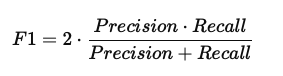
 
То есть F1 высокий только тогда, когда и Precision, и Recall высокие.

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

#создаём knn классификатор
knn = KNeighborsClassifier(n_neighbors=5) 

multi_knn = MultiOutputClassifier(knn)

multi_knn.fit(X_train, y_train) #обучаем

y_pred_knn = multi_knn.predict(X_test) #предсказываем

#проверяем
f1_knn_mean = f1_score(y_test, y_pred_knn, average='macro')  # среднее F1 по всем меткам
print("среднее F1", f1_knn_mean)

f1_knn_target = f1_score(y_test, y_pred_knn, average=None) #по каждой метке
for target, score in zip(y_test.columns, f1_knn_target):
    print(target, score)

F1-score KNN (macro): 0.08766490463651008
acute_toxicity 0.07537688442211055
carcinogenicity 0.0380952380952381
cardiotoxicity 0.3417614833544037
dermal_toxicity 0.05663189269746647
developmental_toxicity 0.0
endocrine_disruption 0.06217616580310881
gastrointestinal_toxicity 0.05089058524173028
genotoxicity 0.40532825880114176
hematotoxicity 0.00796812749003984
hepatotoxicity 0.06779661016949153
immunotoxicity 0.05026455026455026
metabolic_toxicity 0.03424657534246575
musculoskeletal_toxicity 0.027303754266211604
nephrotoxicity 0.022388059701492536
neurotoxicity 0.03868471953578337
ocular_toxicity 0.4195740824648845
other_toxicity 0.03655352480417755
oxidative_stress 0.02247191011235955
reproductive_toxicity 0.007326007326007326
respiratory_toxicity 0.07612456747404844
sensory_toxicity 0.0


Значение KNN очень низкое 

In [ ]:
#пробую в масштабирование
from sklearn.discriminant_analysis import StandardScaler
scaler = StandardScaler()

X = df[feature_columns]
y = df[target_columns]

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

macro_knn = KNeighborsClassifier(n_neighbors=5)
macro_multi_knn = MultiOutputClassifier(knn)


macro_multi_knn.fit(X_train_scaled, y_train) #обучаем

y_pred_macro = macro_multi_knn.predict(X_test_scaled) #предсказываем


#проверяем
macro_f1_knn_mean = f1_score(y_test, y_pred_macro, average='macro')  # среднее F1 по всем меткам
print("F1-score:", macro_f1_knn_mean)

macro_f1_knn_target = f1_score(y_test, y_pred_macro, average=None) #по каждой метке
for target, score in zip(target_cols, macro_f1_knn_target):
    print(target, score)

 


F1-score: 0.14977376869458164
acute_toxicity 0.13969732246798602
carcinogenicity 0.0672782874617737
cardiotoxicity 0.47740440324449596
dermal_toxicity 0.12211668928086838
developmental_toxicity 0.034482758620689655
endocrine_disruption 0.1947449768160742
gastrointestinal_toxicity 0.09069212410501193
genotoxicity 0.5854858548585485
hematotoxicity 0.030418250950570342
hepatotoxicity 0.16842105263157894
immunotoxicity 0.09068627450980392
metabolic_toxicity 0.0462046204620462
musculoskeletal_toxicity 0.033112582781456956
nephrotoxicity 0.06315789473684211
neurotoxicity 0.07692307692307693
ocular_toxicity 0.49851380042462845
other_toxicity 0.08737864077669903
oxidative_stress 0.09693877551020408
reproductive_toxicity 0.03546099290780142
respiratory_toxicity 0.17488076311605724
sensory_toxicity 0.03125


Показатели лучше в 2 раза. 
ТОП - 3:
- cardiotoxicity -  0.477
- genotoxicity 0.585
- ocular_toxicity 0.499

In [ ]:
# В логистическую регрессию
scaler = StandardScaler()
X = df[feature_columns]
y = df[target_columns]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


logistic_regression = LogisticRegression(
    max_iter=500,
    class_weight="balanced", 
    penalty="l2",
    solver="lbfgs"
)

model_log_reg = MultiOutputClassifier(logistic_regression)

model_log_reg.fit(X_train_scaled, y_train) #обучаем

y_pred_log_reg = model_log_reg.predict(X_test_scaled) #предсказываем

#проверяем
f1_mean = f1_score(y_test, y_pred_log_reg, average='macro')  # среднее F1 по всем меткам
print("среднее F1:", f1_mean)

f1_target = f1_score(y_test, y_pred_log_reg, average=None) #по каждой метке
for target, score in zip(target_cols, f1_target):
    print(target, score)



среднее F1: 0.05815967265535216
acute_toxicity 0.052396486825595986
carcinogenicity 0.02646759416355616
cardiotoxicity 0.2945529899348727
dermal_toxicity 0.050186644545831605
developmental_toxicity 0.01374670956420006
endocrine_disruption 0.04582385440363991
gastrointestinal_toxicity 0.030288173448820614
genotoxicity 0.16420487243429888
hematotoxicity 0.018726964837135172
hepatotoxicity 0.03881799213935659
immunotoxicity 0.05085650507109235
metabolic_toxicity 0.022291621796252423
musculoskeletal_toxicity 0.022690083996945564
nephrotoxicity 0.02079871348164031
neurotoxicity 0.03535253227408143
ocular_toxicity 0.2028580814717477
other_toxicity 0.03043847241867044
oxidative_stress 0.02926829268292683
reproductive_toxicity 0.021625536758238917
respiratory_toxicity 0.0348682459409103
sensory_toxicity 0.015092757572581491


Показатели ухудшились практически до первого варианта модели. 
ТОП - 3:
- cardiotoxicity -  0.29
- genotoxicity 0.16
- ocular_toxicity 0.20

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score
#гиперпараметры
X = df[feature_columns]
y = df[target_columns]

# Создание пайплайна
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight='balanced')))
])
# сетка гиперпараметров
param_grid = {
    'clf__estimator__C': [0.01, 0.1, 1, 10], #сила регуляризации
    'clf__estimator__penalty': ['l2'], # тип регуляризации
    'clf__estimator__solver': ['lbfgs'] # алгоритм
}


f1_scorer = make_scorer(f1_score, average='macro')

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=3, 
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"гиперпараметры {grid_search.best_params_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END clf__estimator__C=0.01, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  33.4s
[CV] END clf__estimator__C=0.01, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  34.3s
[CV] END clf__estimator__C=0.01, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  34.4s
[CV] END clf__estimator__C=0.1, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  38.0s
[CV] END clf__estimator__C=0.1, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  39.3s
[CV] END clf__estimator__C=1, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  39.5s
[CV] END clf__estimator__C=0.1, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  39.6s
[CV] END clf__estimator__C=1, clf__estimator__penalty=l2, clf__estimator__solver=lbfgs; total time=  39.8s
[CV] END clf__estimator__C=1, clf__estimator__penalty=l2, clf__estima

In [72]:
model_log_reg = grid_search.best_estimator_

y_pred_log_reg = model_log_reg.predict(X_test) #предсказываем

#проверяем
f1_mean = f1_score(y_test, y_pred_log_reg, average='macro')  # среднее F1 по всем меткам
print("среднее F1:", f1_mean)

f1_target = f1_score(y_test, y_pred_log_reg, average=None) #по каждой метке
for target, score in zip(target_cols, f1_target):
    print(target, score)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


среднее F1: 0.012545613524426862
acute_toxicity 0.013340755715722755
carcinogenicity 0.0057840868985529975
cardiotoxicity 0.0034413535990823058
dermal_toxicity 0.011981665901117051
developmental_toxicity 0.0005070565368038536
endocrine_disruption 0.021244309559939303
gastrointestinal_toxicity 0.00705391345240078
genotoxicity 0.06356252361163581
hematotoxicity 0.004786519278491069
hepatotoxicity 0.010350731301668052
immunotoxicity 0.04006968641114982
metabolic_toxicity 0.005314767601490488
musculoskeletal_toxicity 0.005451461403457168
nephrotoxicity 0.0049821017015642625
neurotoxicity 0.009277200399271915
ocular_toxicity 0.014084507042253521
other_toxicity 0.006839114246521654
oxidative_stress 0.016483516483516484
reproductive_toxicity 0.005060311856428361
respiratory_toxicity 0.010387527142549736
sensory_toxicity 0.003454773869346734


Получилось слабовато. В чем проблема?
- мб слишком мало 1 в датасете
- необходимо изучить зависимости. скорей всего признаки нелинейные